# Sequential Stop Detection

Sequential algorithms scan the dataset searching for consecutive sets of pings contained in a given area for a minimum duration of time. They are intuitive and enjoy linear complexity, with their defining feature being that pings must be consecutive. The containment area that defines a stop can be a circle centered around an anchor point, which can be:
1) the first ping of a candidate stop (sliding)
2) a centroid of a candidate stop, updated with every ping processed

Li et al., [Mining user similarity based on location history](https://dl.acm.org/doi/pdf/10.1145/1463434.1463477).

This implementation relies on 3 parameters:

* `dur_min` defines the minimum duration (in minutes) for a valid stop.
* `delta_roam` specifies the maximum radius (in meters) defining the containment as a circle centered at an anchor point.
* `method` sets the method to define the anchor point, which is the center of the containment area.

In [4]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

# Imports
import nomad.io.base as loader
import geopandas as gpd
from shapely.geometry import box
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings
import nomad.stop_detection.sequential as SEQUENTIAL

# Load data
import nomad.data as data_folder
from pathlib import Path
data_dir = Path(data_folder.__file__).parent
city = gpd.read_parquet(data_dir / 'garden-city-buildings-mercator.parquet')
outer_box = box(*city.total_bounds)

filepath_root = 'gc_data_long/'
tc = {"user_id": "gc_identifier", "x": "dev_x", "y": "dev_y", "timestamp": "unix_ts"}

users = ['admiring_brattain']
traj = loader.sample_from_file(filepath_root, format='parquet', users=users, filters=('date','==', '2024-01-01'), traj_cols=tc)

sequential_stops = SEQUENTIAL.detect_stops(
    data=traj,
    delta_roam=25,
    dt_max=120,
    dur_min=5,
    method='sliding',
    complete_output=True,
    traj_cols=tc
)

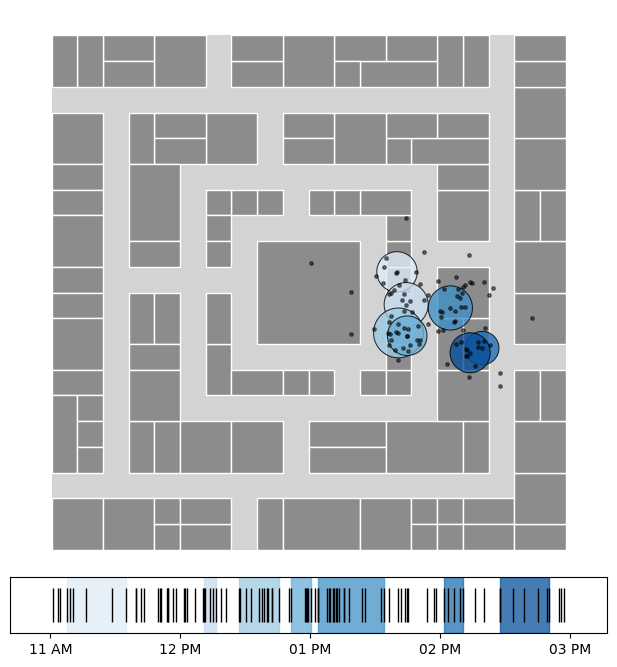

In [5]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

gpd.GeoDataFrame(geometry=[outer_box], crs='EPSG:3857').plot(ax=ax_map, color='#d3d3d3')
city.plot(ax=ax_map, edgecolor='white', linewidth=1, color='#8c8c8c')

plot_stops(sequential_stops, ax=ax_map, cmap='Blues')
plot_pings(traj, ax=ax_map, s=6, color='black', alpha=0.5, traj_cols=tc)
ax_map.set_axis_off()

plot_time_barcode(traj['unix_ts'], ax=ax_barcode, set_xlim=True)
plot_stops_barcode(sequential_stops, ax=ax_barcode, cmap='Blues', set_xlim=False, timestamp='unix_ts')

plt.tight_layout(pad=0.1)
plt.show()